In [1]:
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split

project_path = r"C:\Users\HP\OneDrive\Desktop\AI Traffic Accident Risk Prediction"

data_path = os.path.join(
    project_path,
    "data",
    "UK_Accident.csv"
)

df = pd.read_csv(data_path)

# Remove unnecessary columns
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

if "Accident_Index" in df.columns:
    df.drop(columns=["Accident_Index"], inplace=True)

target = "Accident_Severity"

features = [
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Police_Force",
    "Speed_limit",
    "Light_Conditions",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Special_Conditions_at_Site",
    "Carriageway_Hazards",
    "Urban_or_Rural_Area",
    "Did_Police_Officer_Attend_Scene_of_Accident",
    "Year"
]

X = df[features].copy()
y = df[target].copy()

# Load trained model
model_path = os.path.join(
    project_path,
    "models",
    "best_accident_model.pkl"
)

best_model = joblib.load(model_path)

# Load preprocessing pipeline
preprocessor_path = os.path.join(
    project_path,
    "models",
    "preprocessor.pkl"
)

preprocessor = joblib.load(preprocessor_path)

print("=" * 70)
print("SHAP EXPLAINABILITY - SETUP")
print("=" * 70)

print("Dataset shape:", X.shape)
print("Target:", target)
print("Model:", type(best_model).__name__)
print("Setup completed successfully ✅")

SHAP EXPLAINABILITY - SETUP
Dataset shape: (111, 12)
Target: Accident_Severity
Model: RandomForestClassifier
Setup completed successfully ✅


In [2]:
# Transform the data using the same preprocessing pipeline
X_processed = preprocessor.transform(X)

# Convert to DataFrame
X_processed = pd.DataFrame(
    X_processed,
    columns=preprocessor.get_feature_names_out()
)

print("=" * 70)
print("SHAP DATA PREPARATION")
print("=" * 70)

print("Original data shape :", X.shape)
print("Processed data shape:", X_processed.shape)

print("\nProcessed feature names:")
print(X_processed.columns.tolist())

print("\nSHAP data preparation completed ✅")

SHAP DATA PREPARATION
Original data shape : (111, 12)
Processed data shape: (111, 24)

Processed feature names:
['numerical__Number_of_Vehicles', 'numerical__Number_of_Casualties', 'numerical__Police_Force', 'numerical__Speed_limit', 'numerical__Urban_or_Rural_Area', 'numerical__Year', 'categorical__Light_Conditions_Darkness: Street lighting unknown', 'categorical__Light_Conditions_Darkness: Street lights present and lit', 'categorical__Light_Conditions_Daylight: Street light present', 'categorical__Weather_Conditions_Fine without high winds', 'categorical__Weather_Conditions_Other', 'categorical__Weather_Conditions_Raining without high winds', 'categorical__Weather_Conditions_Snowing without high winds', 'categorical__Weather_Conditions_Unknown', 'categorical__Road_Surface_Conditions_Dry', 'categorical__Road_Surface_Conditions_Frost/Ice', 'categorical__Road_Surface_Conditions_Snow', 'categorical__Road_Surface_Conditions_Wet/Damp', 'categorical__Special_Conditions_at_Site_Auto traffic 

In [6]:
import shap

print("=" * 70)
print("CREATING SHAP EXPLAINER")
print("=" * 70)

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_processed)

print("SHAP values calculated successfully ✅")

print("\nSHAP output type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))

    for i, values in enumerate(shap_values):
        print(
            f"Class {i} SHAP shape:",
            np.array(values).shape
        )

else:
    print(
        "SHAP values shape:",
        np.array(shap_values).shape
    )

CREATING SHAP EXPLAINER
SHAP values calculated successfully ✅

SHAP output type: <class 'numpy.ndarray'>
SHAP values shape: (111, 24, 2)


SHAP FEATURE IMPORTANCE
SHAP values shape: (111, 24, 2)
Feature data shape: (111, 24)


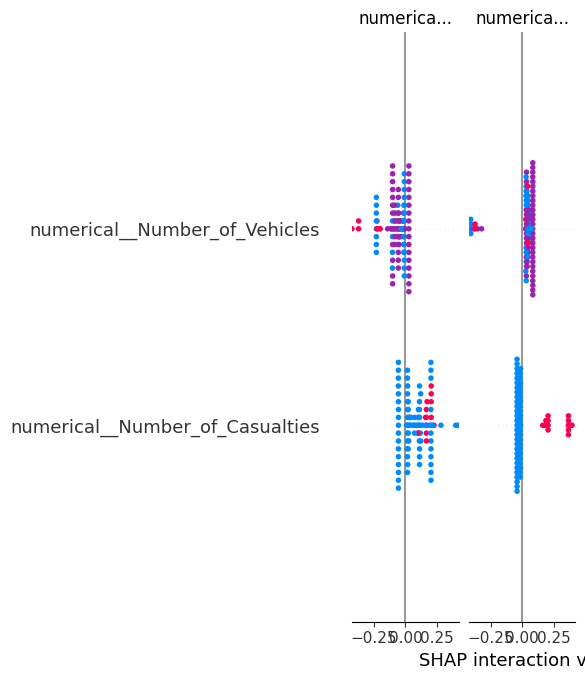

In [7]:
print("=" * 70)
print("SHAP FEATURE IMPORTANCE")
print("=" * 70)

# Handle different SHAP output formats
if isinstance(shap_values, list):

    shap_for_plot = shap_values[-1]

else:

    shap_for_plot = shap_values

# Convert to NumPy array
shap_for_plot = np.array(shap_for_plot)

print("SHAP values shape:", shap_for_plot.shape)
print("Feature data shape:", X_processed.shape)

# Create SHAP summary plot
shap.summary_plot(
    shap_for_plot,
    X_processed,
    show=True
)

INDIVIDUAL ACCIDENT PREDICTION EXPLANATION


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Predicted Accident Severity: 2
Original SHAP shape: (111, 24, 2)
Sample SHAP shape: (24,)
Number of features: 24

Top features influencing this prediction:


,Feature,SHAP_Value
11,categorical__Weather_Conditions_Raining withou...,-0.048632
14,categorical__Road_Surface_Conditions_Dry,0.036243
9,categorical__Weather_Conditions_Fine without h...,-0.025305
23,categorical__Did_Police_Officer_Attend_Scene_o...,0.022849
17,categorical__Road_Surface_Conditions_Wet/Damp,0.018547
1,numerical__Number_of_Casualties,-0.018275
7,categorical__Light_Conditions_Darkness: Street...,-0.017938
22,categorical__Did_Police_Officer_Attend_Scene_o...,0.017855
8,categorical__Light_Conditions_Daylight: Street...,-0.009773
0,numerical__Number_of_Vehicles,0.009140


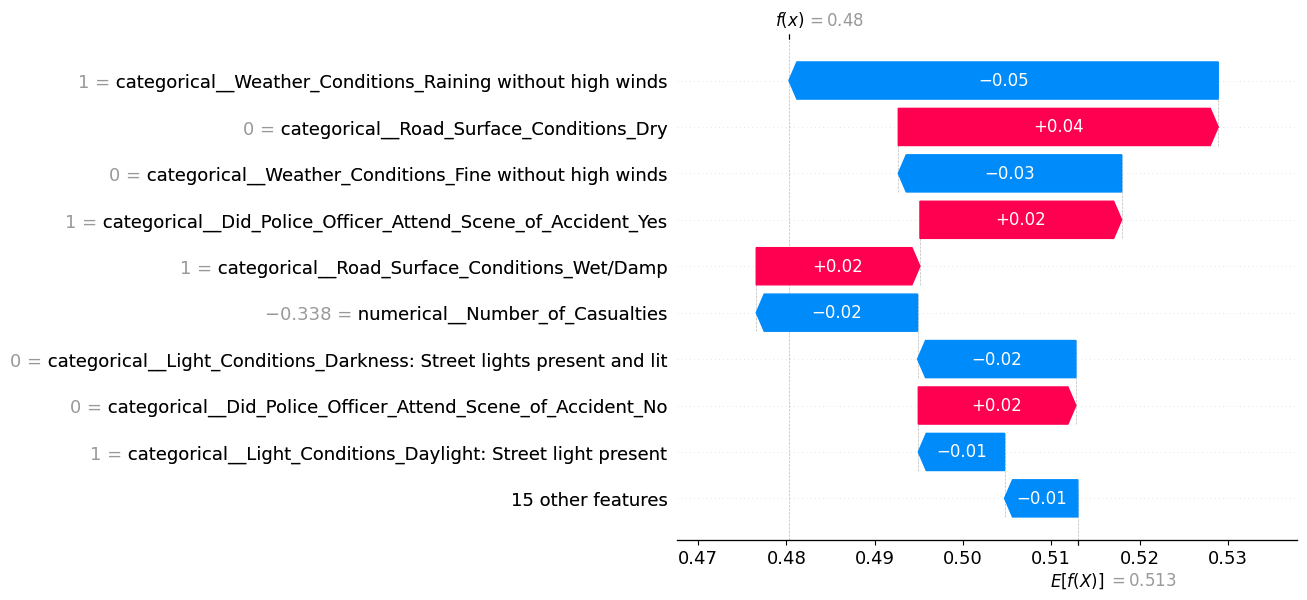

In [9]:
print("=" * 70)
print("INDIVIDUAL ACCIDENT PREDICTION EXPLANATION")
print("=" * 70)

# Select one sample
sample_index = 0
sample = X_processed.iloc[[sample_index]]

# Model prediction
prediction = best_model.predict(sample)[0]

print("Predicted Accident Severity:", prediction)

# ---------------------------------------------------------
# Get SHAP values for the selected sample
# ---------------------------------------------------------

shap_array = np.asarray(shap_values)

print("Original SHAP shape:", shap_array.shape)

# Handle different SHAP output formats
if shap_array.ndim == 3:
    # Shape: (samples, features, classes)
    sample_shap = shap_array[sample_index, :, -1]

elif shap_array.ndim == 2:
    # Shape: (samples, features)
    sample_shap = shap_array[sample_index]

elif shap_array.ndim == 1:
    # Shape: (features,)
    sample_shap = shap_array

else:
    raise ValueError(
        f"Unexpected SHAP shape: {shap_array.shape}"
    )

# Make sure SHAP values are 1-dimensional
sample_shap = np.asarray(sample_shap).flatten()

print("Sample SHAP shape:", sample_shap.shape)
print("Number of features:", len(X_processed.columns))

# ---------------------------------------------------------
# Create explanation table
# ---------------------------------------------------------

explanation = pd.DataFrame({
    "Feature": X_processed.columns,
    "SHAP_Value": sample_shap
})

# Calculate absolute importance
explanation["Absolute_Importance"] = (
    explanation["SHAP_Value"].abs()
)

# Sort by strongest influence
explanation = explanation.sort_values(
    "Absolute_Importance",
    ascending=False
)

print("\nTop features influencing this prediction:")

display(
    explanation[
        ["Feature", "SHAP_Value"]
    ].head(10)
)

# ---------------------------------------------------------
# SHAP Waterfall Plot
# ---------------------------------------------------------

expected_value = explainer.expected_value

if np.asarray(expected_value).ndim > 0:
    base_value = np.asarray(expected_value).flatten()[-1]
else:
    base_value = expected_value

shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap,
        base_values=base_value,
        data=sample.values[0],
        feature_names=X_processed.columns.tolist()
    )
)